In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [2]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)

amip_hist_models        = np.load('./data/helper/amip_hist_models.npy')
amip_piForcing_models   = np.load('./data/helper/amip_piForcing_models.npy')
historical_models       = np.load('./data/helper/historical_models.npy')

amip_hist_n_ensembles       = np.load('./data/helper/amip_hist_n_ensembles.npy')
amip_piForcing_n_ensembles  = np.load('./data/helper/amip_piForcing_n_ensembles.npy')
historical_n_ensembles      = np.load('./data/helper/historical_n_ensembles.npy')

print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)

print(n_time,n_lat,n_lon,n_flat)

amip_hist_models = ['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1']
amip_piForcing_models = ['CESM2' 'CNRM-CM6-1' 'CanESM5' 'HadGEM3-GC31-LL' 'IPSL-CM6A-LR' 'MIROC6'
 'MRI-ESM2-0' 'TaiESM1']
historical_models = ['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CESM2' 'CESM2-FV2'
 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-HR4' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'CanESM5'
 'CanESM5-CanOE' 'E3SM-1-0' 'E3SM-1-1' 'E3SM-1-1-ECA' 'EC-Earth3'
 'EC-Earth3-AerChem' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'FGOALS-g3' 'FIO-ESM-2-0' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6' 'MPI-ESM-1-2-HAM'
 'MPI-ESM1-2-HR'

In [3]:
covRTi_amip_piForcing   = np.load("./data/maps_2000_2014/covRTi_amip_piForcing.npy",allow_pickle=True).item()
covTRi_amip_piForcing   = np.load("./data/maps_2000_2014/covTRi_amip_piForcing.npy",allow_pickle=True).item()
regTiRi_amip_piForcing  = np.load("./data/maps_2000_2014/regTiRi_amip_piForcing.npy",allow_pickle=True).item()

covRTi_amip_hist        = np.load("./data/maps_2000_2014/covRTi_amip_hist.npy",allow_pickle=True).item()
covTRi_amip_hist        = np.load("./data/maps_2000_2014/covTRi_amip_hist.npy",allow_pickle=True).item()
regTiRi_amip_hist       = np.load("./data/maps_2000_2014/regTiRi_amip_hist.npy",allow_pickle=True).item()

covRTi_historical       = np.load("./data/maps_2000_2014/covRTi_historical.npy",allow_pickle=True).item()
covTRi_historical       = np.load("./data/maps_2000_2014/covTRi_historical.npy",allow_pickle=True).item()
regTiRi_historical      = np.load("./data/maps_2000_2014/regTiRi_historical.npy",allow_pickle=True).item()

In [4]:
covRTi_obs    = np.load('./data/maps_2000_2014/covRTi_obs.npy',)
covTRi_obs    = np.load('./data/maps_2000_2014/covTRi_obs.npy',)
regTiRi_obs    = np.load('./data/maps_2000_2014/regTiRi_obs.npy',)

In [5]:
import numpy as np

def subset_latlon(lat, lon, data, lat_bounds, lon_bounds):
    """
    Subset a 2D (lat, lon) data array.

    Parameters
    ----------
    lat : 1D array
    lon : 1D array
    data : 2D array, shape (len(lat), len(lon))
    lat_bounds : (lat_min, lat_max)
    lon_bounds : (lon_min, lon_max)

    Returns
    -------
    2D NumPy array containing the requested region.
    """
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    data = np.asarray(data)

    if data.shape != (lat.size, lon.size):
        raise ValueError(
            f"data shape {data.shape} must equal "
            f"(len(lat), len(lon)) = {(lat.size, lon.size)}"
        )

    lat_min, lat_max = sorted(lat_bounds)
    lon_min, lon_max = sorted(lon_bounds)

    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    lon_mask = (lon >= lon_min) & (lon <= lon_max)

    return data[np.ix_(lat_mask, lon_mask)]

In [6]:
def subset_latlon_with_coords(lat, lon, data, lat_bounds, lon_bounds):
    lat_min, lat_max = sorted(lat_bounds)
    lon_min, lon_max = sorted(lon_bounds)

    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    lon_mask = (lon >= lon_min) & (lon <= lon_max)

    return (
        lat[lat_mask],
        lon[lon_mask],
        data[np.ix_(lat_mask, lon_mask)],
    )

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_map(lat, lon, data):
    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(central_longitude=210)})
    im = ax.pcolormesh(lon, lat, data, shading="auto", transform=ccrs.PlateCarree())
    ax.coastlines()
    fig.colorbar(im, ax=ax)
    plt.show()
    return fig, ax

(72, 144)


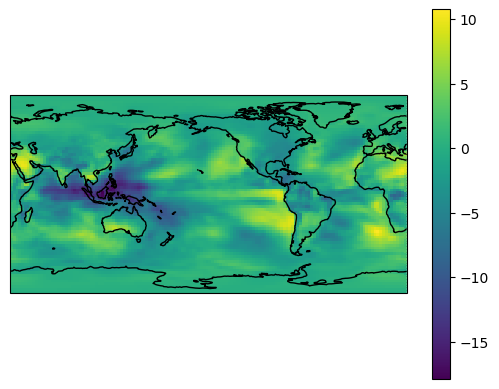

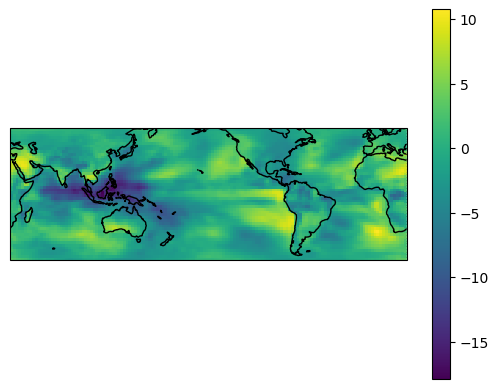

In [8]:
test_data = covRTi_amip_hist['CESM2'][0]
print(test_data.shape)
plot_map(lat,lon,test_data)

lat_sub,lon_sub,data_sub    = subset_latlon_with_coords(lat, lon, test_data, [-60,60], [0,360])
plot_map(lat_sub,lon_sub,data_sub)
data_3030 = subset_latlon(lat, lon, test_data, [-30,30], [0,360])

In [9]:
def weighted_corr(x, y, weights=None):
    if weights is None:
        weights = np.ones_like(x)
    
    wsum = weights.sum()
    x_mean = (weights * x).sum() / wsum
    y_mean = (weights * y).sum() / wsum
    
    xd = x - x_mean
    yd = y - y_mean
    
    cov_xy  = (weights * xd * yd).sum() / wsum
    var_x   = (weights * xd**2).sum() / wsum
    var_y   = (weights * yd**2).sum() / wsum

    corr    = cov_xy / np.sqrt(var_x * var_y)   # Pattern Correlation
    CCC     = 2*cov_xy / (var_x + var_y + (x_mean-y_mean)**2) # Concordance correlation coefficient
    bias    = y_mean - x_mean
    RMSE    = np.sqrt(np.sum(weights*(y-x)**2)/wsum)

    
    return   corr, CCC, bias, RMSE

In [14]:
print(weighted_corr(test_data,covRTi_obs,weights_2D))
print(weighted_corr(data_sub,covRTi_obs_6060,weights_6060))
print(weighted_corr(data_3030,covRTi_obs_3030,weights_3030))


(np.float64(0.583160576012219), np.float64(0.5679113817190524), np.float64(-0.8656491666120473), np.float64(3.6791208187870827))
(np.float64(0.584118136304908), np.float64(0.566757481482627), np.float64(-0.9788868576508163), np.float64(3.9200283462759873))
(np.float64(0.5894652085553725), np.float64(0.565501612469771), np.float64(-1.3481704181359329), np.float64(4.592789638668179))


In [ ]:
kill

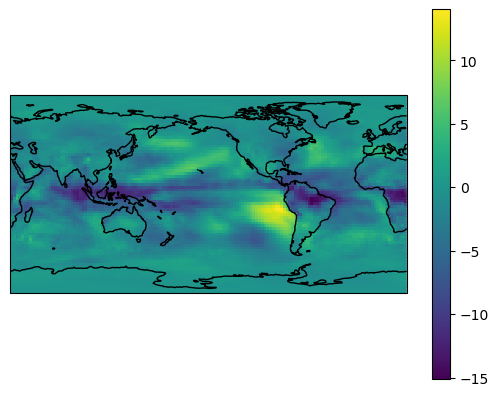

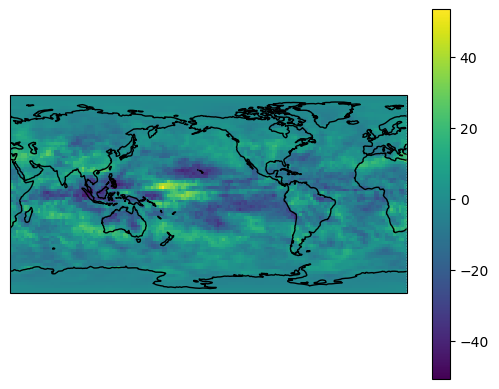

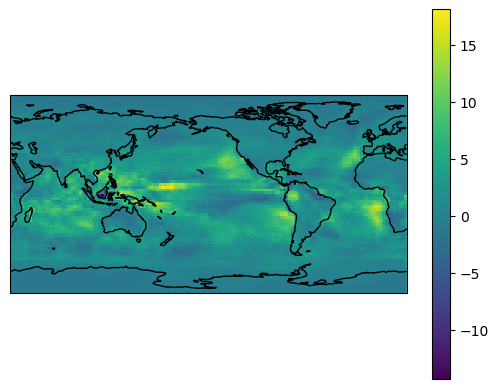

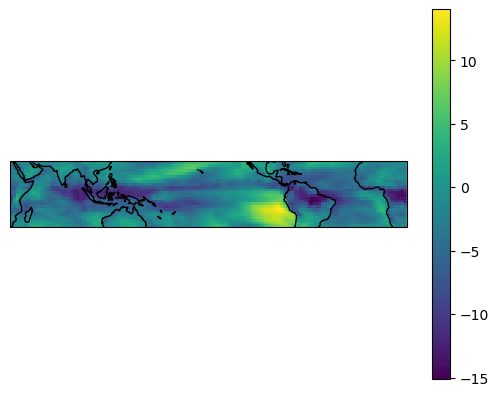

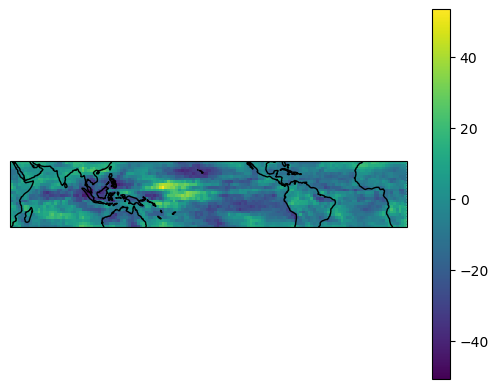

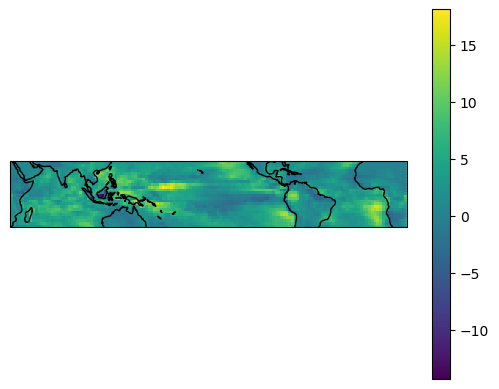

(<Figure size 640x480 with 2 Axes>, <GeoAxes: >)

In [12]:
## Set up obs comparison
weights_2D  = np.array(ERA5['weights'].data)
lat_6060, lon_6060, weights_6060    = subset_latlon_with_coords(lat, lon, weights_2D, [-60,60], [0,360])
lat_3030, lon_3030, weights_3030    = subset_latlon_with_coords(lat, lon, weights_2D, [-30,30], [0,360])

plot_map(lat,lon,covRTi_obs)
plot_map(lat,lon,covTRi_obs)
plot_map(lat,lon,regTiRi_obs)

covRTi_obs_6060     = subset_latlon(lat, lon, covRTi_obs, [-60,60], [0,360])
covTRi_obs_6060     = subset_latlon(lat, lon, covTRi_obs, [-60,60], [0,360])
regTiRi_obs_6060    = subset_latlon(lat, lon, regTiRi_obs, [-60,60], [0,360])

covRTi_obs_3030     = subset_latlon(lat, lon, covRTi_obs, [-30,30], [0,360])
covTRi_obs_3030     = subset_latlon(lat, lon, covTRi_obs, [-30,30], [0,360])
regTiRi_obs_3030    = subset_latlon(lat, lon, regTiRi_obs, [-30,30], [0,360])

# plot_map(lat_6060,lon_6060,covRTi_obs_6060)
# plot_map(lat_6060,lon_6060,covTRi_obs_6060)
# plot_map(lat_6060,lon_6060,regTiRi_obs_6060)

plot_map(lat_3030,lon_3030,covRTi_obs_3030)
plot_map(lat_3030,lon_3030,covTRi_obs_3030)
plot_map(lat_3030,lon_3030,regTiRi_obs_3030)


In [18]:
import numpy as np

experiments = {
    "amip_hist": {
        "covRTi": covRTi_amip_hist,
        "covTRi": covTRi_amip_hist,
        "regTiRi": regTiRi_amip_hist,
    },
    "amip_piForcing": {
        "covRTi": covRTi_amip_piForcing,
        "covTRi": covTRi_amip_piForcing,
        "regTiRi": regTiRi_amip_piForcing,
    },
    "historical": {
        "covRTi": covRTi_historical,
        "covTRi": covTRi_historical,
        "regTiRi": regTiRi_historical,
    },
}

observations = {
    "covRTi": covRTi_obs,
    "covTRi": covTRi_obs,
    "regTiRi": regTiRi_obs,
}

regions = {
    "global": None,
    "6060": ([-60, 60], [0, 360]),
    "3030": ([-30, 30], [0, 360]),
}

metric_names = ("corr", "ccc", "bias", "rmse")
map_similarity = {}

for experiment_name, fields in experiments.items():
    map_similarity[experiment_name] = {}

    for field_name, models in fields.items():
        map_similarity[experiment_name][field_name] = {}

        for region_name, bounds in regions.items():
            map_similarity[experiment_name][field_name][region_name] = {}

            if bounds is None:
                obs_region = observations[field_name]
                weights_region = weights_2D
            else:
                lat_bounds, lon_bounds = bounds
                obs_region = subset_latlon(
                    lat, lon, observations[field_name],
                    lat_bounds, lon_bounds
                )
                weights_region = subset_latlon(
                    lat, lon, weights_2D,
                    lat_bounds, lon_bounds
                )

            for model_name, ensembles in models.items():
                scores = {name: [] for name in metric_names}

                for ensemble in ensembles:
                    ensemble_region = (
                        ensemble if bounds is None
                        else subset_latlon(
                            lat, lon, ensemble,
                            lat_bounds, lon_bounds
                        )
                    )

                    values = weighted_corr(
                        obs_region,
                        ensemble_region,
                        weights=weights_region
                    )

                    for metric_name, value in zip(metric_names, values):
                        scores[metric_name].append(value)

                map_similarity[experiment_name][field_name][region_name][model_name] = {
                    name: np.asarray(values)
                    for name, values in scores.items()
                }

In [30]:
# import pickle

# output = {
#     "map_similarity": map_similarity,
#     "regions": regions,
#     "metric_names": metric_names,
# }

# with open("./data/maps_2000_2014/map_similarity.pkl", "wb") as f:
#     pickle.dump(output, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("./data/maps_2000_2014/map_similarity.pkl", "rb") as f:
    output = pickle.load(f)

map_similarity = output["map_similarity"]
regions = output["regions"]
metric_names = output["metric_names"]

In [26]:
map_similarity_3030 = {
    experiment: {
        field: region_data["3030"]
        for field, region_data in fields.items()
    }
    for experiment, fields in map_similarity.items()
}